In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xmf6
from denit import gwf, gwt, plot, utils
linea = 50*chr(0x2015)

In [2]:
def test():
    filename = "remix/DENIT-10.xlsx"
    denit_excel = pd.read_excel(filename, 
                                skiprows=2, 
                                header=None).drop(columns=[0])
    ncomp = 7 
    icp = 11
    return denit_excel.iloc[icp:icp+ncomp, 1:11].to_numpy(dtype=float)

In [3]:
#
# --- DEFINICIÓN DE LAS RUTAS Y NOMBRES ---
#
paths = dict(
    # Ejecutable de Modflow: WINDOWS
    mf6_exe = r"C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\mf6",
    mf6_dll = r"C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\libmf6.dll",
    #
    # Nombre de los modelos y espacios de trabajo
    flow_name = "flow",
    flow_ws = "mf6_gwf_gwt_comp",
    tran_name = "transport",
    tran_ws = "mf6_gwf_gwt_comp",
    #
    # Nombre de los archivos de datos
    u_init = os.path.join("remix", "u_init.dat"),
    u_tilde = os.path.join("remix", "u_tilde.dat"),
    u_new = os.path.join("remix", "u_new.out"),
    #
    # Ejecutable REMIX y archivo de entrada
    remix_exe = os.path.join("remix", "bin", "interfaz_remix.exe"),
    remix_input = os.path.join("datos_interfaz_denit_2reacts"),
)
paths["command"] = f"{paths["remix_exe"]} < {paths["remix_input"]}"
#
# --- DEFINIENDO CONDICIONES INICIALES ---
#
print(linea)
print("Generating initial conditions".center(50))
components, _ = utils.initial_conditions(paths, comp = True)
ncomp = len(components["names"])
#components["init_conc"] = test()
print(linea)
#
xmf6.nice_print(paths, "Paths and filenames")
#
# --- DATOS PARA LA SIMULACIÓN ---
#
# Paso del tiempo
dt = 1.0e-0
NT = 10
#
# Discretización del espacio
nlay, nrow, ncol = 1, 1, 10
delr, delc, delz = 0.1, 0.1, 0.1 
dis = {
    'length_units' : "meters",
    'nlay': nlay, 
    'nrow': nrow, 
    'ncol': ncol,
    'delr': delr, 
    'delc': delc, 
    'top' : delz, 
    'botm': 0.0 
}
xmf6.nice_print(dis, "Spatial discretization")
#
# Parámetros físicos.
phys = dict(
    perioddata = [(dt, 1, 1.0)], #PERLEN, NSTP, TSMULT
    porosity = 0.5,  # Porosity of mobile domain (unitless)
    hydraulic_conductivity = 1.0,  # Hydraulic conductivity ($cm s^{-1}$)
    specific_discharge = 0.2,  # Specific discharge ($cm s^{-1}$)
    longitudinal_dispersivity = 1.0,
    components = components["names"], # Components names
    source_concentration = components["ext_water"],  # Source concentration (unitless)
    initial_concentration = components["init_conc"], # Initial concentration (unitless)
)
xmf6.nice_print(phys, "Physical parameters")

――――――――――――――――――――――――――――――――――――――――――――――――――
          Generating initial conditions           
-> File remix\u_init.dat already exist
――――――――――――――――――――――――――――――――――――――――――――――――――

Paths and filenames
―――――――――――――――――――
    mf6_exe = C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\mf6
    mf6_dll = C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\libmf6.dll
  flow_name = flow
    flow_ws = mf6_gwf_gwt_comp
  tran_name = transport
    tran_ws = mf6_gwf_gwt_comp
     u_init = remix\u_init.dat
    u_tilde = remix\u_tilde.dat
      u_new = remix\u_new.out
  remix_exe = remix\bin\interfaz_remix.exe
remix_input = datos_interfaz_denit_2reacts
    command = remix\bin\interfaz_remix.exe < datos_interfaz_denit_2reacts
―――――――――――――――――――

Spatial discretization
――――――――――――――――――――――
length_units = meters
        nlay = 1
        nrow = 1
        ncol = 10
        delr = 0.1
        delc = 0.1
         top = 0.1
        botm = 0.0
――――――――――――――――――――――

Physi

In [4]:
u_tilde = [0 for i in range(0,ncomp)]

for it in range(1, NT+1):
    print(linea)
    print(f"Step = {it}, time = {it * dt}d".center(50))
    print(linea)

    for m in range(0, ncomp):
        #
        # - ACTUALIZACION DEL FLUJO CON GWF ---
        #
        # --- Construcción de la simulación de flujo
        o_sim_f = gwf.build(phys, dis, m, paths)
        #
        # --- Ejecución de la simulación ---
        print(" GWF", end = "")
        o_sim_f.run_simulation(silent=True)
        #
        # - SIMULACIÓN DE TRANSPORTE CON GWT PARA CADA COMPONENTE
        #
        # --- Construcción de la simulación de transporte
        o_sim_t = gwt.build(phys, dis, m, paths)
        #
        # --- Ejecución de la simulación de transporte ---
        print(f"-GWT: C{m+1}", end= " |")
        o_sim_t.run_simulation(silent=True)
        #
        # --- Obtenemos la concentración calculada por GWT
        u_tilde[m] = utils.get_conc(o_sim_t)
    #
    # --- Guardamos concentraciones en "u_tilde.dat"
    print("\n-> Writting: u_tilde.dat")
    with open(paths["u_tilde"], "w") as f:
        for a in u_tilde:
            f.writelines(" ".join([c for c in a.astype(str)]))
            f.write("\n")
    #
    # ---- Ejecutamos REMIX usando las nuevas concentraciones
    print(f"-> Executing: {paths["command"]}\n")
    ret = os.system(paths["command"])
    print(f"\n-> Error code: {ret}")
    #
    # --- Leemos las concentraciones de las componentes calculadas por REMIX
    print(f"-> Reading: {paths["u_new"]}")
    with open(paths["u_new"], "r") as f:
        lines = f.readlines()
    #
    # Actualizamos las concentraciones para GWT
    key_string = "Aqueous component concentrations after solving reactive mixing iteration (rows: components, columns: targets):"
    iccn = utils.find_index(lines, key_string, 2)
    u_new = [np.array(l.split(), dtype=float) for l in lines[iccn:iccn+ncomp]]
    phys["initial_concentration"] = u_new


――――――――――――――――――――――――――――――――――――――――――――――――――
              Step = 1, time = 1.0d               
――――――――――――――――――――――――――――――――――――――――――――――――――
 GWF-GWT: C1 | GWF-GWT: C2 | GWF-GWT: C3 | GWF-GWT: C4 | GWF-GWT: C5 | GWF-GWT: C6 | GWF-GWT: C7 |
-> Writting: u_tilde.dat
-> Executing: remix\bin\interfaz_remix.exe < datos_interfaz_denit_2reacts


-> Error code: 0
-> Reading: remix\u_new.out
――――――――――――――――――――――――――――――――――――――――――――――――――
              Step = 2, time = 2.0d               
――――――――――――――――――――――――――――――――――――――――――――――――――
 GWF-GWT: C1 | GWF-GWT: C2 | GWF-GWT: C3 | GWF-GWT: C4 | GWF-GWT: C5 | GWF-GWT: C6 | GWF-GWT: C7 |
-> Writting: u_tilde.dat
-> Executing: remix\bin\interfaz_remix.exe < datos_interfaz_denit_2reacts


-> Error code: 0
-> Reading: remix\u_new.out
――――――――――――――――――――――――――――――――――――――――――――――――――
              Step = 3, time = 3.0d               
――――――――――――――――――――――――――――――――――――――――――――――――――
 GWF-GWT: C1 | GWF-GWT: C2 | GWF-GWT: C3 | GWF-GWT:

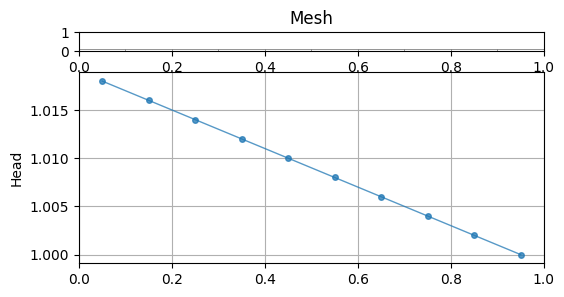

In [5]:
o_gwf, head, x, y, z = utils.get_head(o_sim_f)
plot.show_f(o_gwf, head, x, y, z)

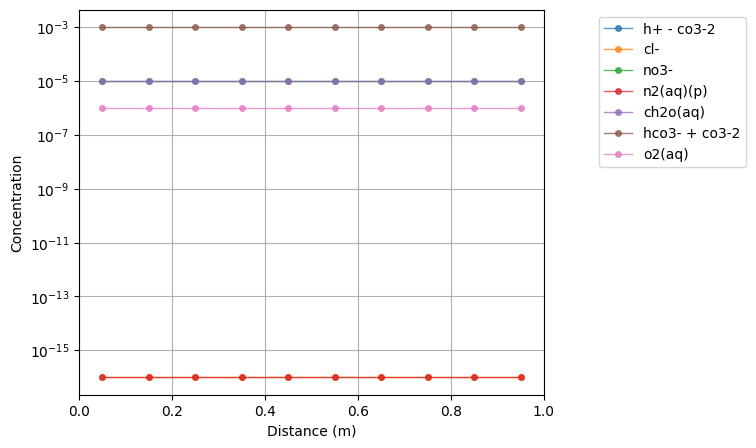

In [6]:
plot.show_t(components["init_conc"], components["names"], x, y, z, "log")

In [7]:
print(components["init_conc"])

[array([-3.69029e-07, -3.69029e-07, -3.69029e-07, -3.69029e-07,
       -3.69029e-07, -3.69029e-07, -3.69029e-07, -3.69029e-07,
       -3.69029e-07, -3.69029e-07]), array([1.e-16, 1.e-16, 1.e-16, 1.e-16, 1.e-16, 1.e-16, 1.e-16, 1.e-16,
       1.e-16, 1.e-16]), array([1.e-05, 1.e-05, 1.e-05, 1.e-05, 1.e-05, 1.e-05, 1.e-05, 1.e-05,
       1.e-05, 1.e-05]), array([1.e-16, 1.e-16, 1.e-16, 1.e-16, 1.e-16, 1.e-16, 1.e-16, 1.e-16,
       1.e-16, 1.e-16]), array([1.e-05, 1.e-05, 1.e-05, 1.e-05, 1.e-05, 1.e-05, 1.e-05, 1.e-05,
       1.e-05, 1.e-05]), array([0.00100047, 0.00100047, 0.00100047, 0.00100047, 0.00100047,
       0.00100047, 0.00100047, 0.00100047, 0.00100047, 0.00100047]), array([1.e-06, 1.e-06, 1.e-06, 1.e-06, 1.e-06, 1.e-06, 1.e-06, 1.e-06,
       1.e-06, 1.e-06])]


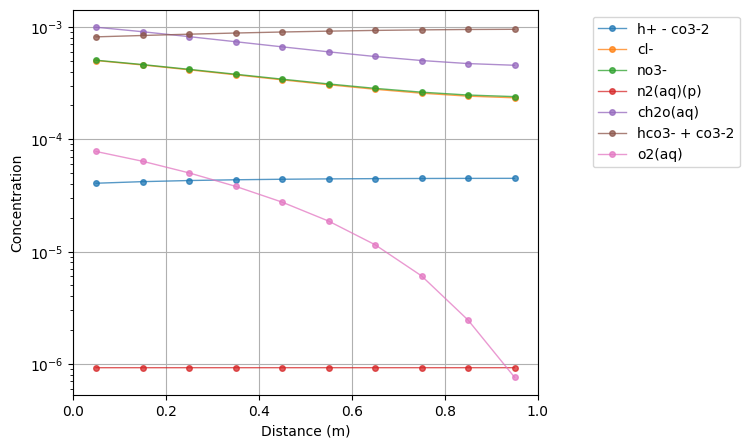

In [11]:
plot.show_t(u_new, components["names"], x, y, z, "log")

In [9]:
print(u_new)

[array([4.05474e-05, 4.18939e-05, 4.28589e-05, 4.35347e-05, 4.40057e-05,
       4.43319e-05, 4.45544e-05, 4.47018e-05, 4.47921e-05, 4.48360e-05]), array([0.00050196, 0.00045843, 0.00041505, 0.00037465, 0.00033797,
       0.00030568, 0.00027846, 0.00025694, 0.00024183, 0.00023383]), array([0.00050546, 0.00046227, 0.00041923, 0.00037916, 0.00034278,
       0.00031077, 0.00028377, 0.00026245, 0.00024746, 0.00023954]), array([9.23303e-07, 9.23333e-07, 9.23350e-07, 9.23363e-07, 9.23370e-07,
       9.23374e-07, 9.23377e-07, 9.23379e-07, 9.23380e-07, 9.23381e-07]), array([0.00099394, 0.00090655, 0.00081952, 0.00073848, 0.00066488,
       0.00060006, 0.00054535, 0.0005021 , 0.00047168, 0.00045558]), array([0.00081568, 0.00083886, 0.00086157, 0.00088242, 0.00090108,
       0.0009173 , 0.00093083, 0.00094142, 0.00094882, 0.00095272]), array([7.77829e-05, 6.36512e-05, 5.01377e-05, 3.80624e-05, 2.75472e-05,
       1.86717e-05, 1.14954e-05, 6.06873e-06, 2.45404e-06, 7.59427e-07])]
